## 2. Data Importation

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt, log, exp

# Load the IMDb dataset
import kagglehub

# Download the latest version of the IMDb dataset
dataset_path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
df = pd.read_csv(f"{dataset_path}/IMDB Dataset.csv")

# Display the first few rows of the dataset
print(df.head())

100%|██████████| 25.7M/25.7M [00:01<00:00, 13.5MB/s]

Extracting files...


                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [2]:
# Display the shape of the dataset (number of rows and columns)
print("Dataset shape:", df.shape)

# Display the first few rows of the dataset
print(df.head())

# Display dataset information
print(df.info())

# Display descriptive statistics of the dataset
print(df.describe())

Dataset shape: (50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None
                                                   review sentiment
count                                               50000     50000
unique                                              49582         2
top     Loved today's show!!! It was a variety and not...  positive
freq         

Unique values in column 'review': ["One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main 

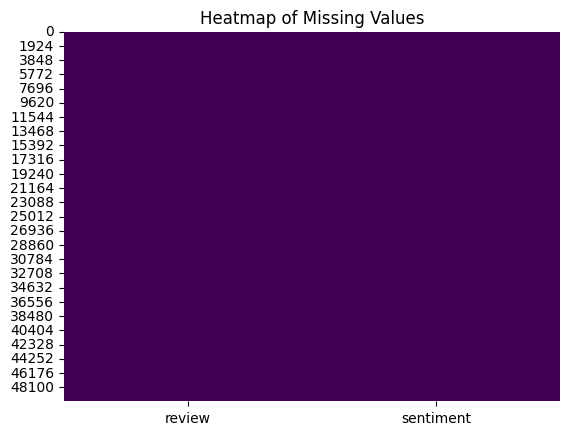

In [3]:
# Display unique values in each column
for col in df.columns:
    print(f"Unique values in column '{col}': {df[col].unique()}")

# Replace missing values (if any)
df = df.replace('?', np.nan)

# Display the number of missing values per column
print("Missing values per column:")
print(df.isnull().sum())

# Visualize missing values
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.show()

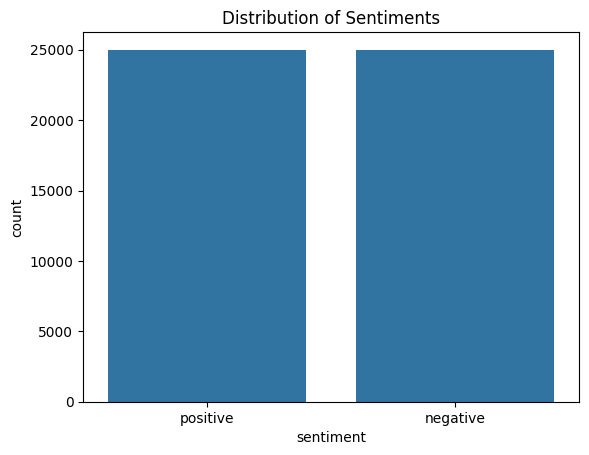

In [4]:
# Distribution of sentiment labels
sns.countplot(x='sentiment', data=df)
plt.title('Distribution of Sentiments')
plt.show()

count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review_length, dtype: float64


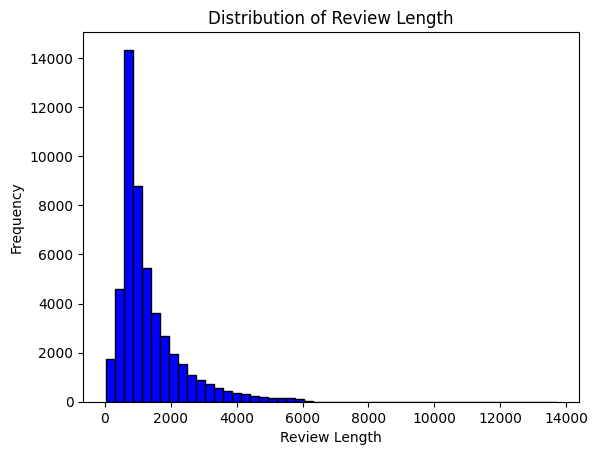

In [5]:
# Add a column with the length of the reviews
df['review_length'] = df['review'].apply(len)

# Descriptive statistics of review length
print(df['review_length'].describe())

# Histogram of review length
plt.hist(df['review_length'], bins=50, color='blue', edgecolor='black')
plt.title('Distribution of Review Length')
plt.xlabel('Review Length')
plt.ylabel('Frequency')
plt.show()

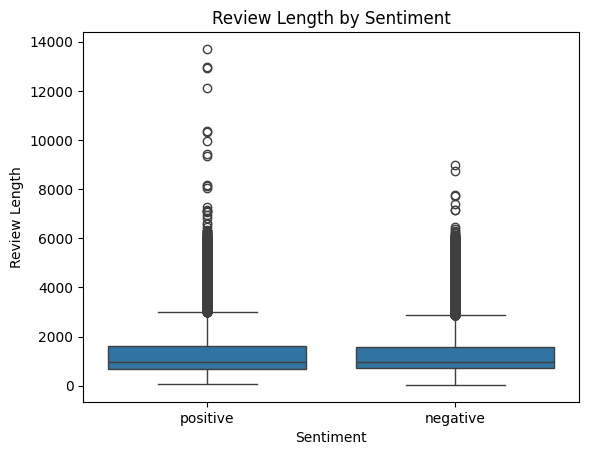

In [6]:
# Boxplot of review length by sentiment
sns.boxplot(x='sentiment', y='review_length', data=df)
plt.title('Review Length by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Review Length')
plt.show()

##  Data Understanding

Mean review length: 1309.43102


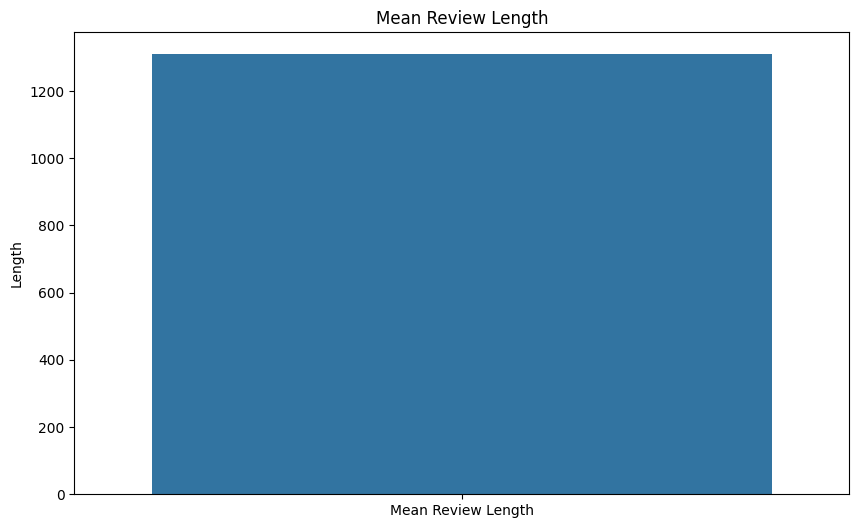

In [7]:
# Calculate and display the mean of review lengths
mean_review_length = df['review_length'].mean()
print(f"Mean review length: {mean_review_length}")

# Plot the mean review length
plt.figure(figsize=(10, 6))
sns.barplot(x=['Mean Review Length'], y=[mean_review_length])
plt.title('Mean Review Length')
plt.ylabel('Length')
plt.show()

Trimmed mean review length: 1132.8872


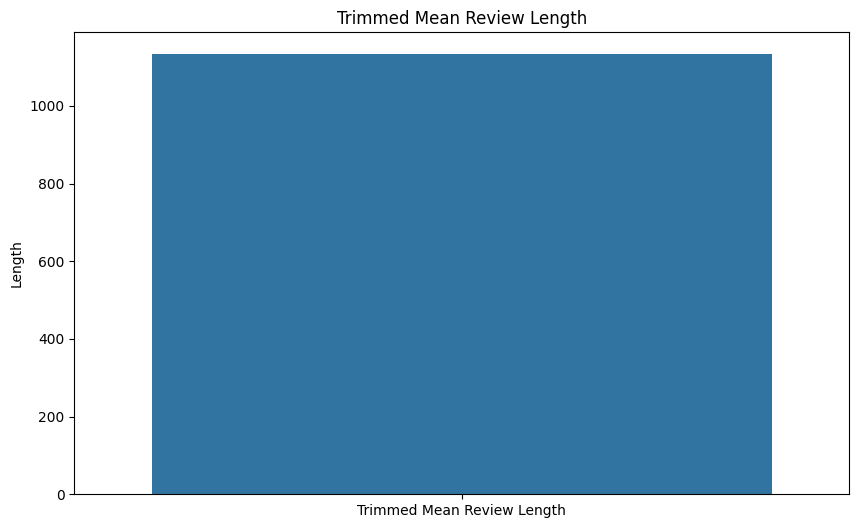

In [8]:
# Calculate and display the trimmed mean of review lengths
from scipy.stats import trim_mean

trimmed_mean_review_length = trim_mean(df['review_length'], proportiontocut=0.1)
print(f"Trimmed mean review length: {trimmed_mean_review_length}")

# Plot the trimmed mean review length
plt.figure(figsize=(10, 6))
sns.barplot(x=['Trimmed Mean Review Length'], y=[trimmed_mean_review_length])
plt.title('Trimmed Mean Review Length')
plt.ylabel('Length')
plt.show()

Median review length: 970.0


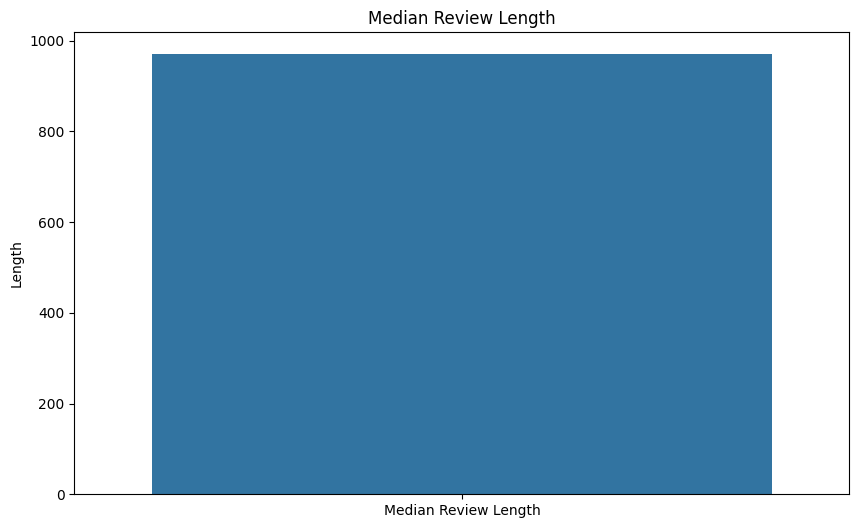

In [9]:
# Calculate and display the median of review lengths
median_review_length = df['review_length'].median()
print(f"Median review length: {median_review_length}")

# Plot the median review length
plt.figure(figsize=(10, 6))
sns.barplot(x=['Median Review Length'], y=[median_review_length])
plt.title('Median Review Length')
plt.ylabel('Length')
plt.show()

Mode review length: 658


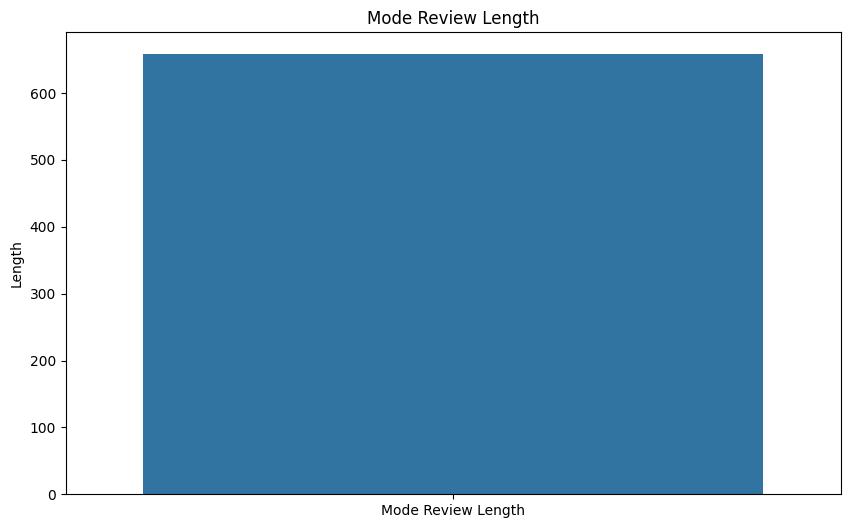

In [10]:
# Calculate and display the mode of review lengths
mode_review_length = df['review_length'].mode()[0]
print(f"Mode review length: {mode_review_length}")

# Plot the mode review length
plt.figure(figsize=(10, 6))
sns.barplot(x=['Mode Review Length'], y=[mode_review_length])
plt.title('Mode Review Length')
plt.ylabel('Length')
plt.show()

Max review length: 13704


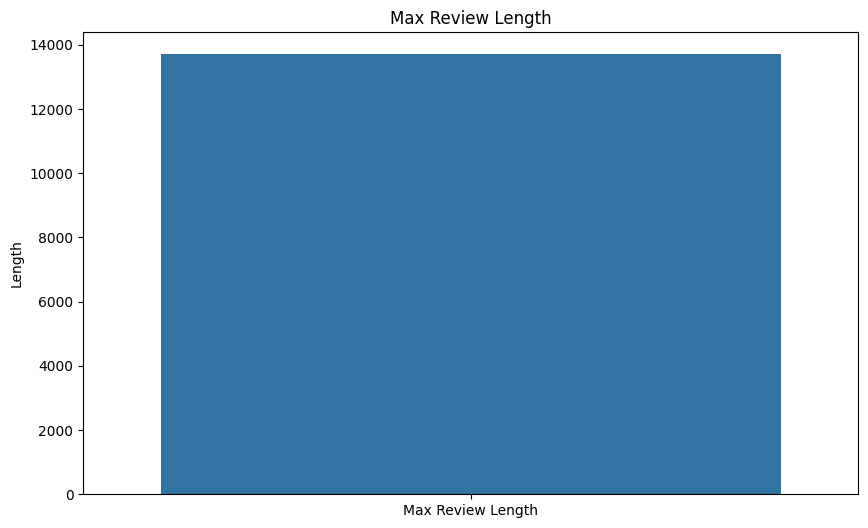

In [11]:
# Calculate and display the maximum review length
max_review_length = df['review_length'].max()
print(f"Max review length: {max_review_length}")

# Plot the maximum review length
plt.figure(figsize=(10, 6))
sns.barplot(x=['Max Review Length'], y=[max_review_length])
plt.title('Max Review Length')
plt.ylabel('Length')
plt.show()

Min review length: 32


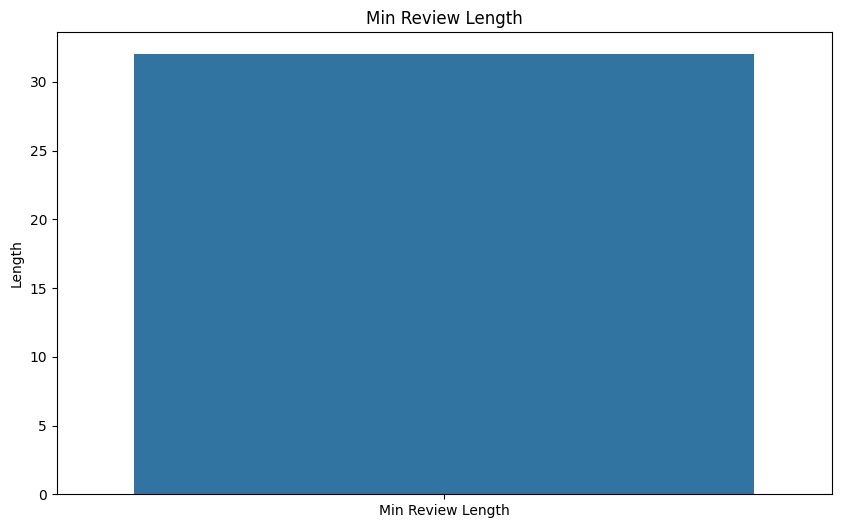

In [12]:
# Calculate and display the minimum review length
min_review_length = df['review_length'].min()
print(f"Min review length: {min_review_length}")

# Plot the minimum review length
plt.figure(figsize=(10, 6))
sns.barplot(x=['Min Review Length'], y=[min_review_length])
plt.title('Min Review Length')
plt.ylabel('Length')
plt.show()

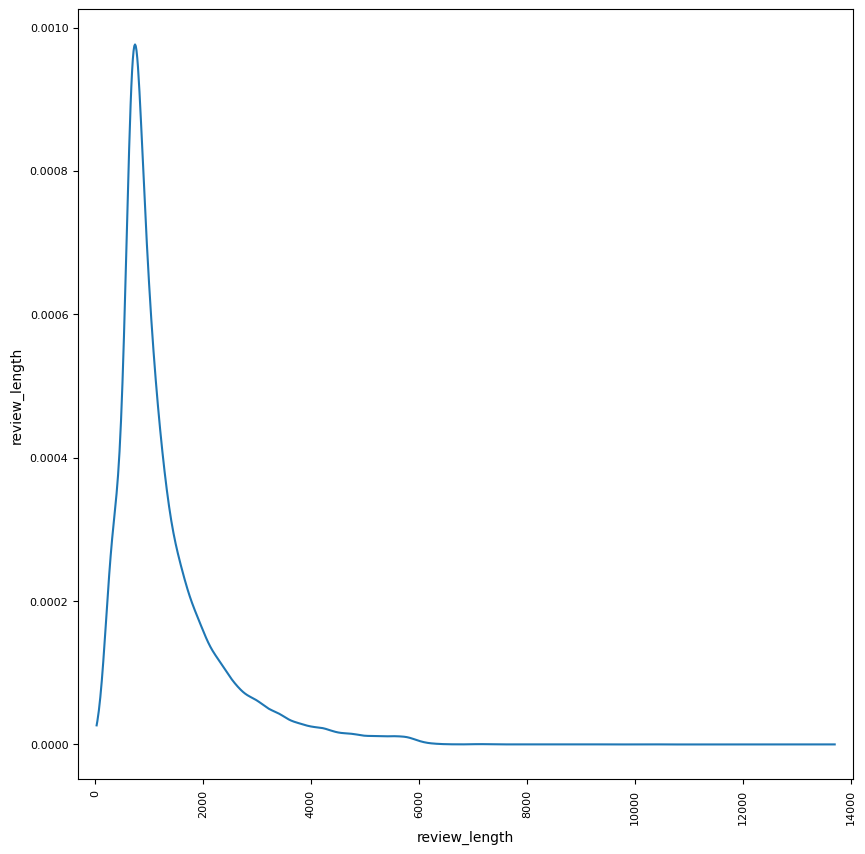

In [13]:
# Gaussian Distribution
from pandas.plotting import scatter_matrix

# Plot scatter matrix for the dataset
scatter_matrix(df[['review_length']], alpha=0.2, figsize=(10, 10), diagonal='kde')
plt.show()

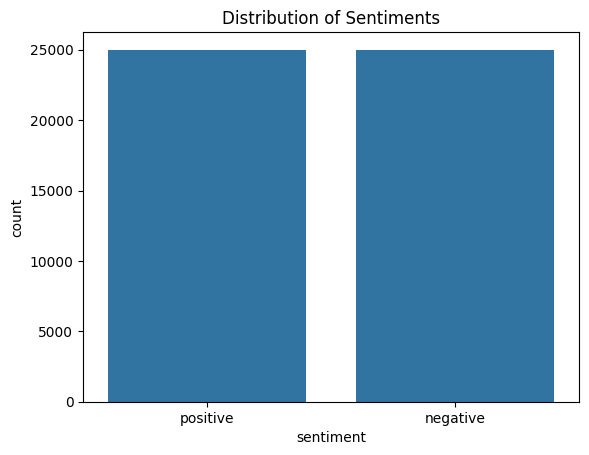

In [14]:
# Distribution of sentiment labels
sns.countplot(x='sentiment', data=df)
plt.title('Distribution of Sentiments')
plt.show()

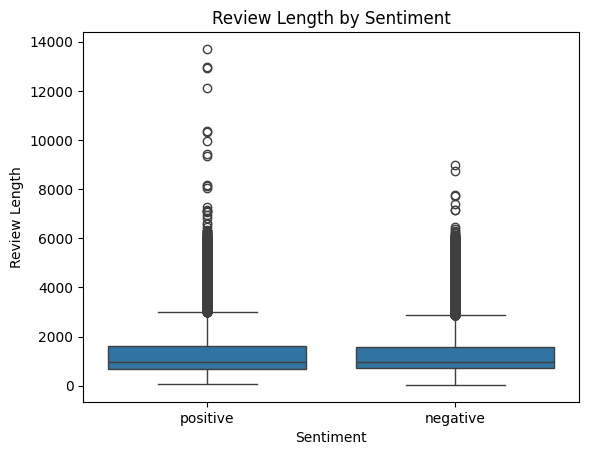

In [15]:
# Boxplot of review length by sentiment
sns.boxplot(x='sentiment', y='review_length', data=df)
plt.title('Review Length by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Review Length')
plt.show()

review           0
sentiment        0
review_length    0
dtype: int64


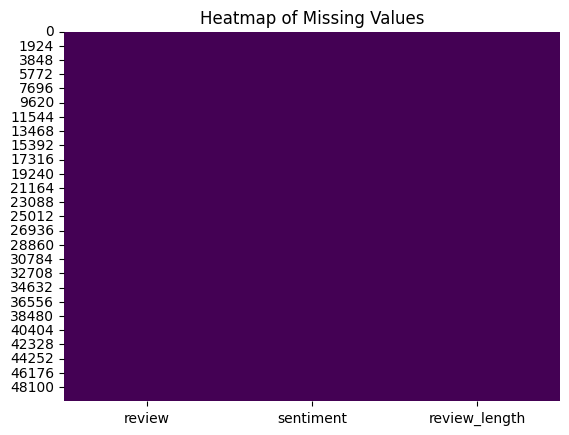

In [16]:
# Analysis of missing values
print(df.isnull().sum())

# Visualize missing values
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.show()

In [17]:
# Display unique values in each column
for col in df.columns:
    print(f"Unique values in column '{col}': {df[col].unique()}")

Unique values in column 'review': ["One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main 

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


[('the', 573398), (',', 544030), ('.', 467982), ('and', 309118), ('a', 309103), ('of', 285087), ('to', 263658), ('is', 214740), ('/', 202455), ('>', 202250), ('<', 202094), ('br', 201948), ('in', 173139), ('I', 163294), ('it', 151931), ('that', 137744), ("'s", 121769), ('this', 120442), ('was', 99090), ('The', 87819)]


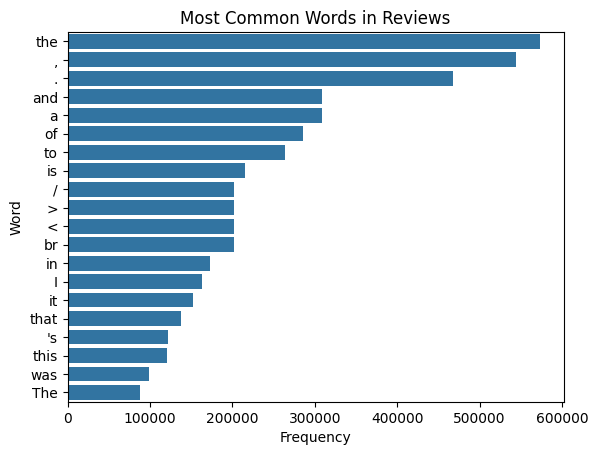

In [19]:
from collections import Counter
from nltk.tokenize import word_tokenize
import nltk

# Download NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')

# Tokenize the reviews
df['tokens'] = df['review'].apply(word_tokenize)

# Count the frequency of words
all_words = [word for tokens in df['tokens'] for word in tokens]
word_freq = Counter(all_words)

# Display the 20 most common words
print(word_freq.most_common(20))

# Visualize the most common words
common_words = pd.DataFrame(word_freq.most_common(20), columns=['Word', 'Frequency'])
sns.barplot(x='Frequency', y='Word', data=common_words)
plt.title('Most Common Words in Reviews')
plt.show()

## 4. Pre-processing des données

### 4-1 Data cleaning

Missing values

Missing values per column:
review           0
sentiment        0
review_length    0
tokens           0
dtype: int64


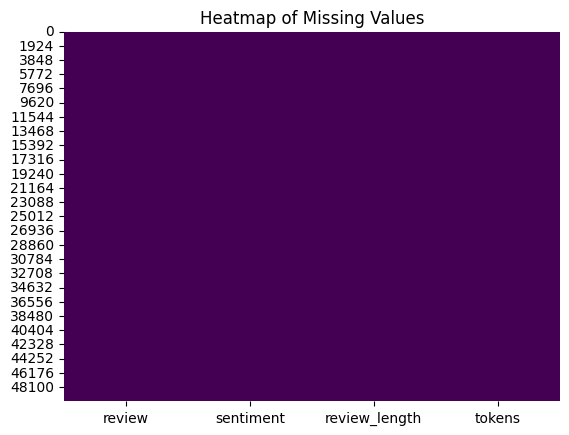

In [20]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

# Visualize missing values
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.show()

Outliers

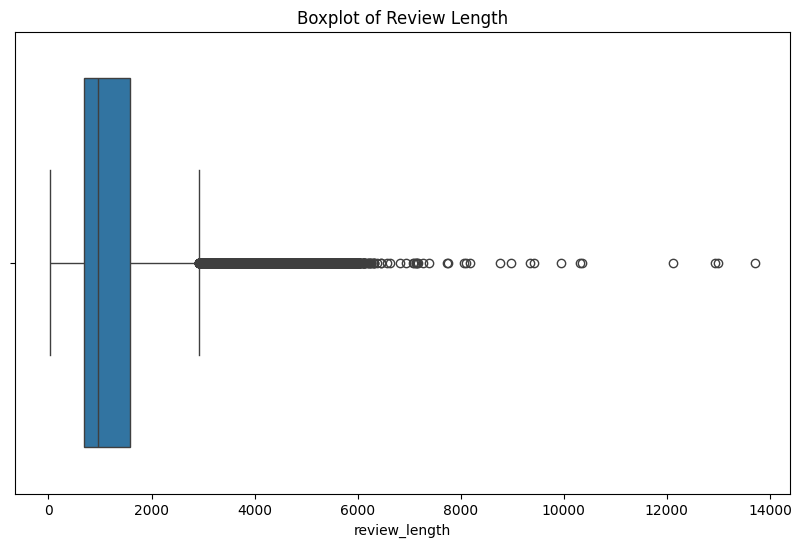

Number of rows after removing outliers: 46263


In [21]:
# Add a column with the length of the reviews
df['review_length'] = df['review'].apply(len)

# Plot boxplot to visualize outliers in review length
plt.figure(figsize=(10, 6))
sns.boxplot(x='review_length', data=df)
plt.title('Boxplot of Review Length')
plt.show()

# Remove outliers based on review length
Q1 = df['review_length'].quantile(0.25)
Q3 = df['review_length'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['review_length'] >= lower_bound) & (df['review_length'] <= upper_bound)]
print(f"Number of rows after removing outliers: {df.shape[0]}")

Doublons

In [22]:
# Check for duplicates, excluding columns with unhashable types (e.g., lists)
columns_to_check = df.columns.difference(['tokens'])  # Exclude 'tokens' column if it contains lists
duplicates = df[columns_to_check].duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Remove duplicates
df = df.drop_duplicates(subset=columns_to_check)
print(f"Number of rows after removing duplicates: {df.shape[0]}")

Number of duplicate rows: 399
Number of rows after removing duplicates: 45864


### 4-2 Data Transformation

Imbalanced data

sentiment
0    23025
1    22839
Name: count, dtype: int64
sentiment
0    23025
1    23025
Name: count, dtype: int64


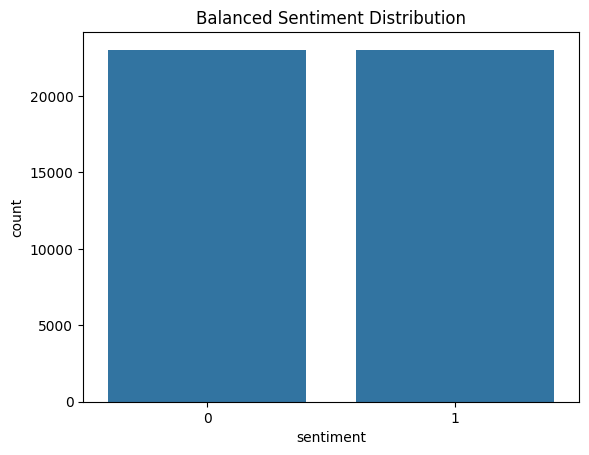

In [23]:
# Encode sentiment labels as binary values
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Check the distribution of sentiment labels
print(df['sentiment'].value_counts())

# Perform oversampling to balance the dataset
from sklearn.utils import resample

# Separate majority and minority classes
df_majority = df[df['sentiment'] == 0]
df_minority = df[df['sentiment'] == 1]

# Upsample minority class
df_minority_upsampled = resample(df_minority,
                                 replace=True,    # sample with replacement
                                 n_samples=len(df_majority), # to match majority class
                                 random_state=42)  # reproducible results

# Combine majority class with upsampled minority class
df_balanced = pd.concat([df_majority, df_minority_upsampled])

# Display new class counts
print(df_balanced['sentiment'].value_counts())

# Visualize the balanced dataset
sns.countplot(x='sentiment', data=df_balanced)
plt.title('Balanced Sentiment Distribution')
plt.show()

Gaussian Distribution

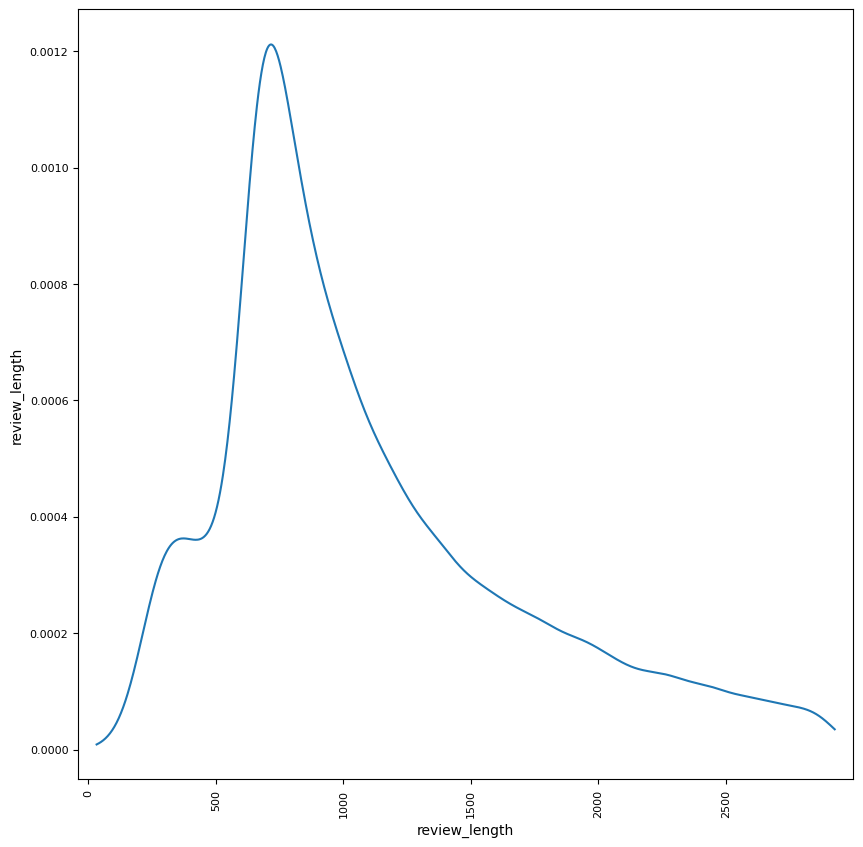

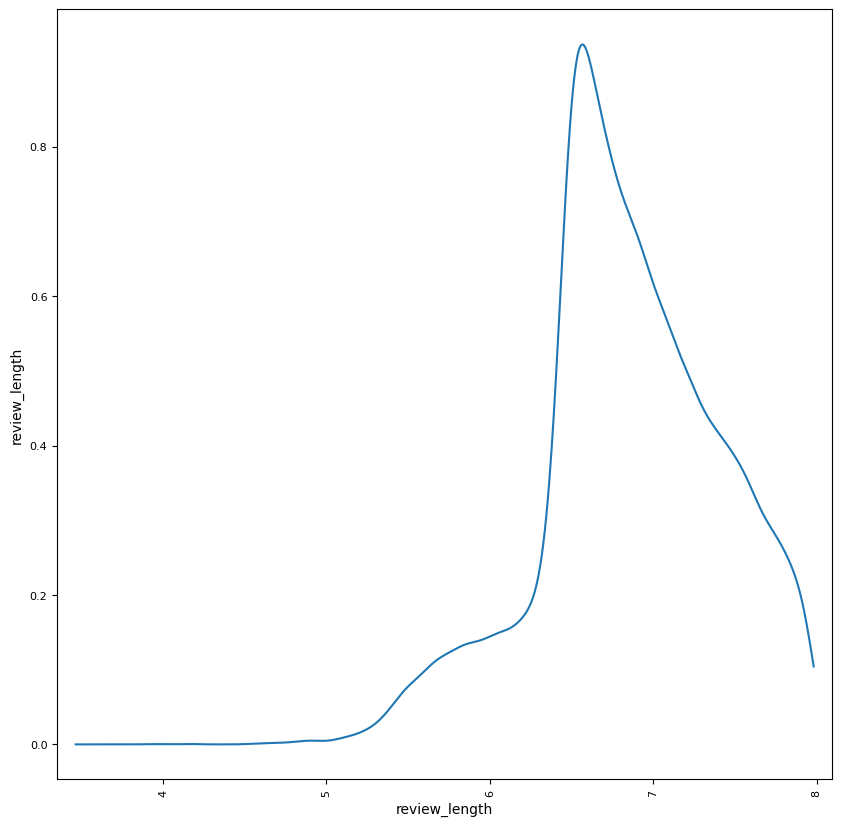

In [24]:
# Gaussian Distribution
from pandas.plotting import scatter_matrix

# Plot scatter matrix for the dataset
scatter_matrix(df_balanced[['review_length']], alpha=0.2, figsize=(10, 10), diagonal='kde')
plt.show()

# Apply log transformation to review length
df_balanced['review_length'] = df_balanced['review_length'].map(lambda x: log(x))

# Plot scatter matrix after transformation
scatter_matrix(df_balanced[['review_length']], alpha=0.2, figsize=(10, 10), diagonal='kde')
plt.show()

### 4-3 Data Reduction

Suppression de quelques colonnes

In [25]:
# Drop unnecessary columns
df_reduced = df_balanced.drop(columns=['review'])

# Display the first few rows of the reduced dataset
print(df_reduced.head())

    sentiment  review_length  \
3           0       6.617403   
7           0       6.839476   
8           0       6.523562   
10          0       6.359574   
11          0       6.842683   

                                               tokens  
3   [Basically, there, 's, a, family, where, a, li...  
7   [This, show, was, an, amazing, ,, fresh, &, in...  
8   [Encouraged, by, the, positive, comments, abou...  
10  [Phil, the, Alien, is, one, of, those, quirky,...  
11  [I, saw, this, movie, when, I, was, about, 12,...  


Affichage de la matrice de corrélation

    sentiment  review_length
3           0       6.617403
7           0       6.839476
8           0       6.523562
10          0       6.359574
11          0       6.842683


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


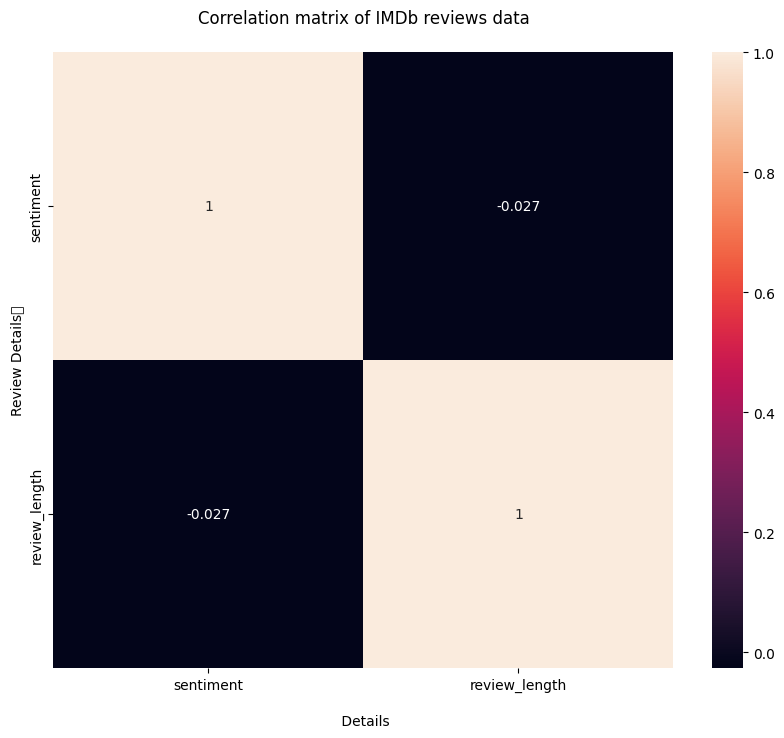

In [27]:
# Drop unnecessary columns, including 'tokens' column
df_reduced = df_balanced.drop(columns=['review', 'tokens'])

# Display the first few rows of the reduced dataset
print(df_reduced.head())

# Display the correlation matrix
a4_dims = (10, 8)
fig, ax = plt.subplots(figsize=a4_dims)

hm = sns.heatmap(ax=ax, data=df_reduced.corr(), annot=True)
hm.set(xlabel='\n Details', ylabel='Review Details\t', title="Correlation matrix of IMDb reviews data\n")

plt.show()

## 5. Data Analysis

Text Preprocessing

In [28]:
# Download NLTK resources
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Preprocess the text
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['cleaned_review'] = df['review'].apply(preprocess_text)

# Display the first few rows of the preprocessed dataset
print(df[['review', 'cleaned_review']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                      cleaned_review  
0  one reviewer mentioned watching oz episode hoo...  
1  wonderful little production br br filming tech...  
2  thought wonderful way spend time hot summer we...  
3  basically family little boy jake think zombie ...  
4  petter mattei love time money visually stunnin...  


Frequency of being positive or negative by review length

<ipython-input-29-72e193dba2f6>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['sentiment'] == 1]['review_length'], label="Positive")
<ipython-input-29-72e193dba2f6>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['sentiment'] == 0]['review_length'], label="Negative")


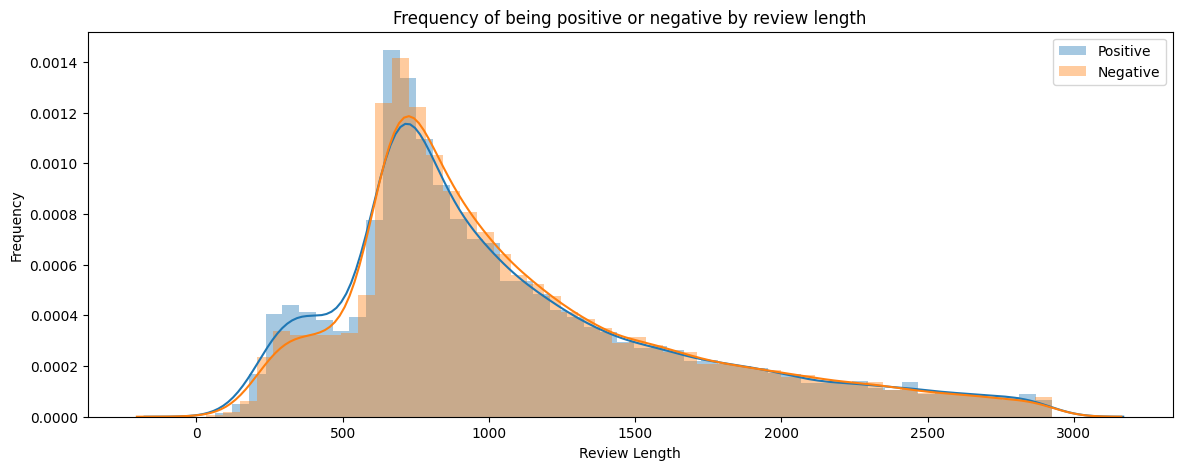

In [29]:
# Frequency of being positive or negative by review length
plt.figure(figsize=(14, 5))
sns.distplot(df[df['sentiment'] == 1]['review_length'], label="Positive")
sns.distplot(df[df['sentiment'] == 0]['review_length'], label="Negative")
plt.legend()
plt.title("Frequency of being positive or negative by review length")
plt.xlabel('Review Length')
plt.ylabel('Frequency')
plt.show()

Frequency of being positive or negative by word count

<ipython-input-30-8168dca37e7f>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['sentiment'] == 1]['word_count'], label="Positive")
<ipython-input-30-8168dca37e7f>:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['sentiment'] == 0]['word_count'], label="Negative")


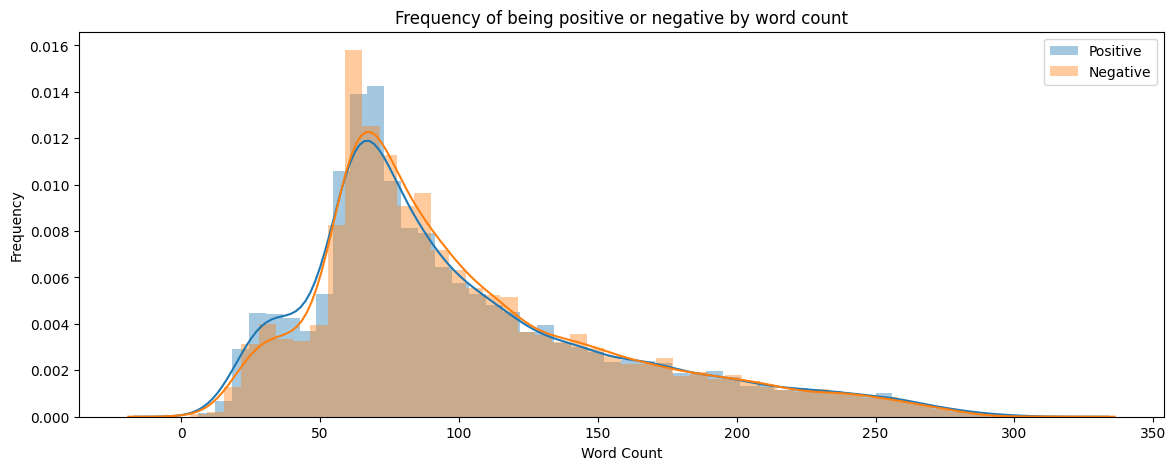

In [30]:
# Add a column with the word count of the reviews
df['word_count'] = df['cleaned_review'].apply(lambda x: len(x.split()))

# Frequency of being positive or negative by word count
plt.figure(figsize=(14, 5))
sns.distplot(df[df['sentiment'] == 1]['word_count'], label="Positive")
sns.distplot(df[df['sentiment'] == 0]['word_count'], label="Negative")
plt.legend()
plt.title("Frequency of being positive or negative by word count")
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

Frequency of being positive or negative by sentiment

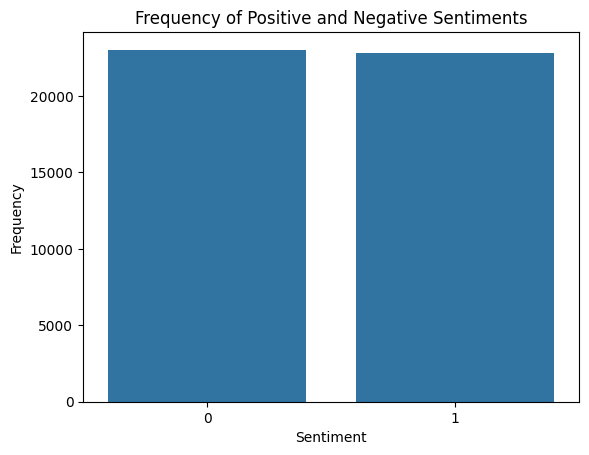

In [31]:
# Frequency of being positive or negative by sentiment
sns.countplot(x='sentiment', data=df)
plt.title('Frequency of Positive and Negative Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Frequency')
plt.show()

Frequency of being positive or negative by most common words

Most common words in positive reviews:
br           74048
movie        39245
film         38299
one          21688
like         14396
time         12800
good         12712
story        11344
great        11167
character    10558
see          10479
well         10202
really        8805
get           8751
make          8632
also          8211
would         8044
show          7878
life          7489
love          7489
Name: count, dtype: int64
Most common words in negative reviews:
br           81141
movie        50694
film         35054
one          21728
like         18383
bad          12670
good         12443
even         12278
time         12199
would        11315
character    11195
get          10564
make         10512
really       10243
see           9097
story         9012
scene         8771
much          8104
people        7617
could         7551
Name: count, dtype: int64


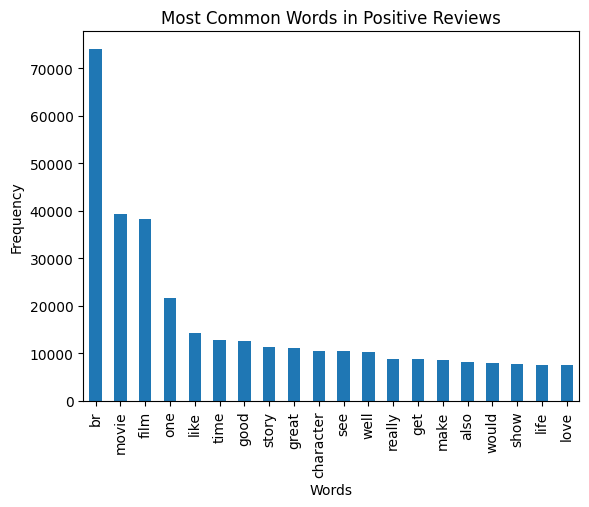

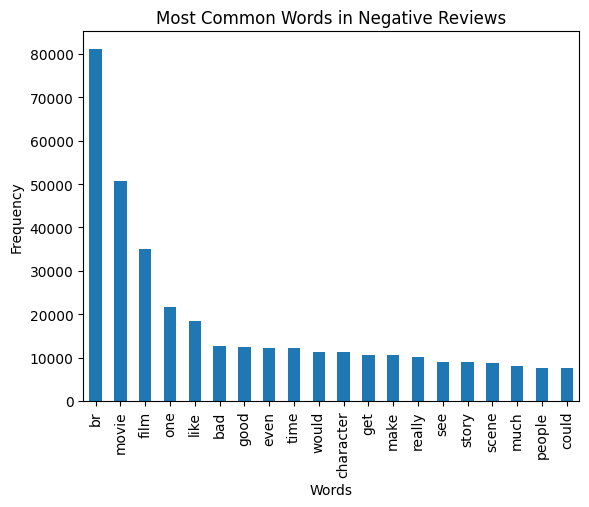

In [32]:
# Frequency of being positive or negative by most common words
positive_words = df[df['sentiment'] == 1]['cleaned_review'].str.split(expand=True).stack().value_counts()
negative_words = df[df['sentiment'] == 0]['cleaned_review'].str.split(expand=True).stack().value_counts()

# Display the 20 most common words in positive reviews
print("Most common words in positive reviews:")
print(positive_words.head(20))

# Display the 20 most common words in negative reviews
print("Most common words in negative reviews:")
print(negative_words.head(20))

# Visualize the most common words in positive reviews
positive_words.head(20).plot(kind='bar', title='Most Common Words in Positive Reviews')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

# Visualize the most common words in negative reviews
negative_words.head(20).plot(kind='bar', title='Most Common Words in Negative Reviews')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

In [33]:
!pip install wordcloud
!pip install tensorflow

In [34]:
!pip install --upgrade pip

!pip install --upgrade Pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 31.6 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


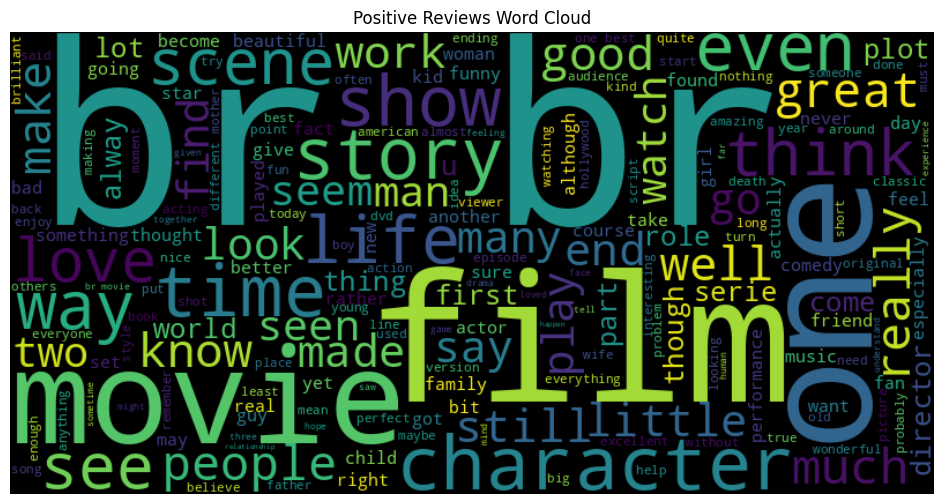

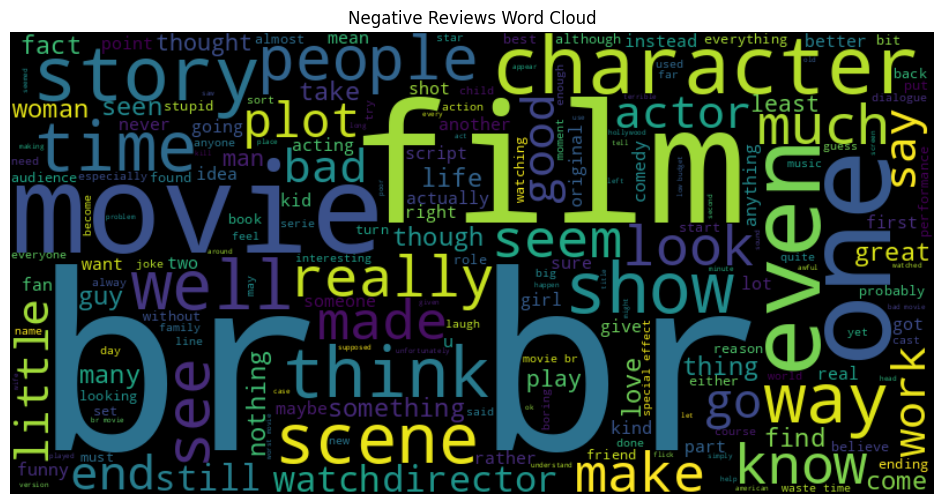

In [35]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Generate word clouds
positive_text = ' '.join(df[df['sentiment'] == 1]['cleaned_review'])
negative_text = ' '.join(df[df['sentiment'] == 0]['cleaned_review'])

# Generate word cloud for positive reviews
plt.figure(figsize=(12, 6))
wordcloud = WordCloud(width=800, height=400).generate(positive_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Positive Reviews Word Cloud')
plt.axis('off')
plt.show()

# Generate word cloud for negative reviews
plt.figure(figsize=(12, 6))
wordcloud = WordCloud(width=800, height=400).generate(negative_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Negative Reviews Word Cloud')
plt.axis('off')
plt.show()

Most common words in positive reviews:
br           74048
movie        39245
film         38299
one          21688
like         14396
time         12800
good         12712
story        11344
great        11167
character    10558
see          10479
well         10202
really        8805
get           8751
make          8632
also          8211
would         8044
show          7878
life          7489
love          7489
scene         7428
even          7094
much          7035
people        6998
first         6988
best          6979
way           6685
think         6205
year          6035
watch         6015
Name: count, dtype: int64
Most common words in negative reviews:
br           81141
movie        50694
film         35054
one          21728
like         18383
bad          12670
good         12443
even         12278
time         12199
would        11315
character    11195
get          10564
make         10512
really       10243
see           9097
story         9012
scene         8771
muc

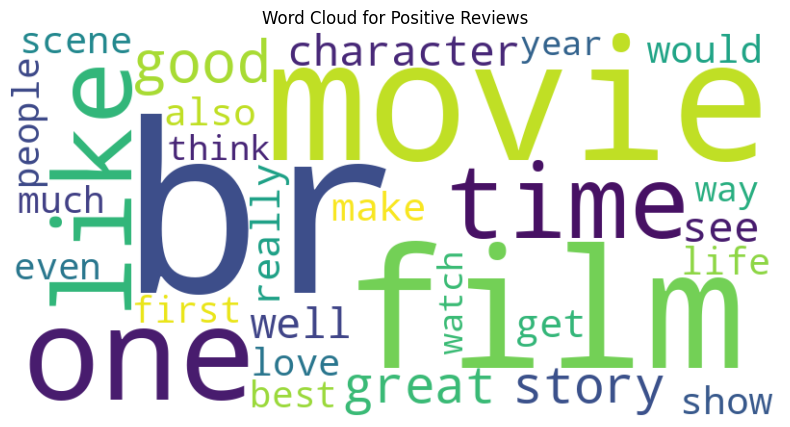

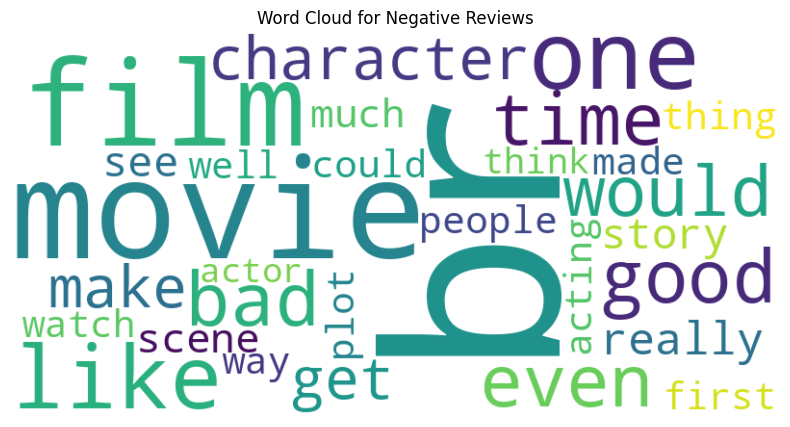

In [37]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# Frequency of being positive or negative by most common words
positive_words = df[df['sentiment'] == 1]['cleaned_review'].str.split(expand=True).stack().value_counts()
negative_words = df[df['sentiment'] == 0]['cleaned_review'].str.split(expand=True).stack().value_counts()

# Display the 30 most common words in positive reviews
print("Most common words in positive reviews:")
print(positive_words.head(30))

# Display the 30 most common words in negative reviews
print("Most common words in negative reviews:")
print(negative_words.head(30))

# Convert the frequencies to dictionaries
positive_word_freq = positive_words.head(30).to_dict()
negative_word_freq = negative_words.head(30).to_dict()

# Generate word cloud for positive reviews
positive_wordcloud = WordCloud(width=800, height=400, background_color='white', font_path=None).generate_from_frequencies(positive_word_freq)
plt.figure(figsize=(10, 5))
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Positive Reviews')
plt.show()

# Generate word cloud for negative reviews
negative_wordcloud = WordCloud(width=800, height=400, background_color='white', font_path=None).generate_from_frequencies(negative_word_freq)
plt.figure(figsize=(10, 5))
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Negative Reviews')
plt.show()